# Chapter 11 - Modelling time series with gated RNN: LSTM & GRU

In [ ]:
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from timeseries import normalize_series
from Chapter10.utils import create_sliding_windows, plot_training, plot_prediction
from Chapter10.models import train, predict, TimeSeriesGatedRNN

## Data

### Load

In [3]:
def get_data():
    data_file = "tdaily_cet.dat.txt"
    f = open(data_file)
    data = f.read()
    f.close()
    lines = data.split('\n')
    temperatures=[]
    for line in lines:
        if line:
            linedata = line.split(' ')
            temperatures.append(float(linedata[1]))

    series = np.asarray(temperatures)
    time = np.arange(len(temperatures), dtype="float32")
    return time, series

In [4]:
# load data
time, series = get_data()
series_normalized = normalize_series(series)

### Samples

In [5]:
# First create the full windowed dataset
series_tensor = torch.tensor(series_normalized, dtype=torch.float32)
window_size = 60
features, targets = create_sliding_windows(series_tensor, window_size=window_size, shift=1)

In [6]:
split_location = 80000

features = features.unsqueeze(1)
# Create the full dataset
full_dataset = TensorDataset(features, targets)

# Calculate split indices
# Note: Since we're using windows, we need to account for the overlap
train_size = split_location - window_size + 1  # Adjust for window overlap
total_windows = len(full_dataset)
train_indices = list(range(train_size))
val_indices = list(range(train_size, total_windows))

# Create training and validation datasets using Subset
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

### `DataLoader`

Original series length: 91502
Total number of windows: 91443
Training windows: 79941
Validation windows: 11502

Example Training Batch:
Batch shape - Features: torch.Size([128, 1, 59]), Targets: torch.Size([128, 1])

Example Validation Batch:
Batch shape - Features: torch.Size([128, 1, 59]), Targets: torch.Size([128, 1])


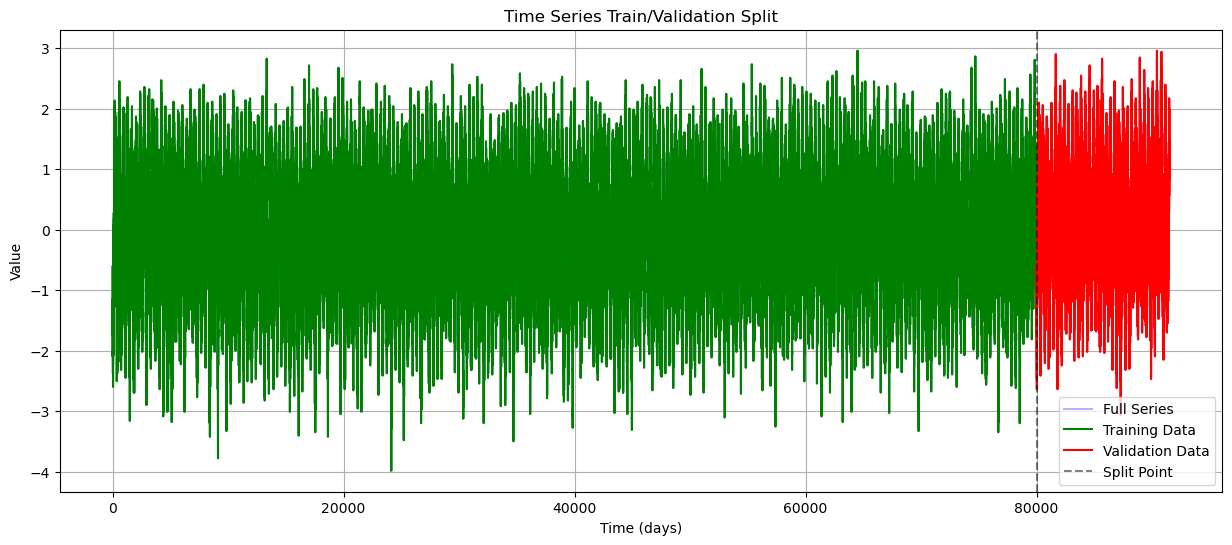

In [7]:
batch_size = 128

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print information about the splits
print(f"Original series length: {len(series_normalized)}")
print(f"Total number of windows: {total_windows}")
print(f"Training windows: {len(train_dataset)}")
print(f"Validation windows: {len(val_dataset)}")

# Show example batch from each
print("\nExample Training Batch:")
train_features, train_targets = next(iter(train_loader))
print(f"Batch shape - Features: {train_features.shape}, Targets: {train_targets.shape}")

print("\nExample Validation Batch:")
val_features, val_targets = next(iter(val_loader))
print(f"Batch shape - Features: {val_features.shape}, Targets: {val_targets.shape}")

# Visualize the split point
plt.figure(figsize=(15, 6))
plt.plot(range(len(series_normalized)), series_normalized, 'b-', label='Full Series', alpha=0.3)
plt.plot(range(split_location), series_normalized[:split_location], 'g-', label='Training Data')
plt.plot(range(split_location, len(series_normalized)), series_normalized[split_location:], 'r-', label='Validation Data')
plt.axvline(x=split_location, color='k', linestyle='--', alpha=0.5, label='Split Point')
plt.title('Time Series Train/Validation Split')
plt.xlabel('Time (days)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Model

In [8]:
epochs = 100
learning_rate = 0.0005
dropout_rate = 0.1
hidden_size = 100
patience = None

### GRU

In [10]:
# class TimeSeriesGRU(nn.Module):
#     def __init__(self, input_size=1, hidden_size=100, output_size=1, dropout_rate=0.3):
#         super(TimeSeriesGRU, self).__init__()

#         self.rnn1 = nn.GRU(input_size=input_size,
#                           hidden_size=hidden_size,
#                           batch_first=True,
#                           dropout=dropout_rate)  # Add dropout to RNN

#         self.rnn2 = nn.GRU(input_size=hidden_size,
#                           hidden_size=hidden_size,
#                           batch_first=True,
#                           dropout=dropout_rate)  # Add dropout to RNN

#         # Add more layers before final output
#         self.fc1 = nn.Linear(hidden_size, hidden_size)
#         self.relu = nn.ReLU()
#         self.linear = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out1, _ = self.rnn1(x)
#         out2, _ = self.rnn2(out1)
#         out2 = out2[:, -1, :]
#         out3 = self.relu(self.fc1(out2))
#         output = self.linear(out3)
#         return output

/home/casadoj/miniconda3/envs/torch/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
Epoch 10/100: 100%|██████████| 625/625 [00:03<00:00, 186.90it/s]


Epoch [10 / 100], Train Loss: 0.1103, Val Loss: 0.0957


Epoch 20/100: 100%|██████████| 625/625 [00:03<00:00, 189.82it/s]


Epoch [20 / 100], Train Loss: 0.1099, Val Loss: 0.0981


Epoch 30/100: 100%|██████████| 625/625 [00:03<00:00, 171.45it/s]


...

Epoch [80 / 100], Train Loss: 0.1003, Val Loss: 0.0988


Epoch 90/100: 100%|██████████| 625/625 [00:03<00:00, 197.84it/s]


Epoch [90 / 100], Train Loss: 0.0979, Val Loss: 0.1007


Epoch 100/100: 100%|██████████| 625/625 [00:03<00:00, 200.12it/s]


Epoch [100 / 100], Train Loss: 0.0946, Val Loss: 0.1025


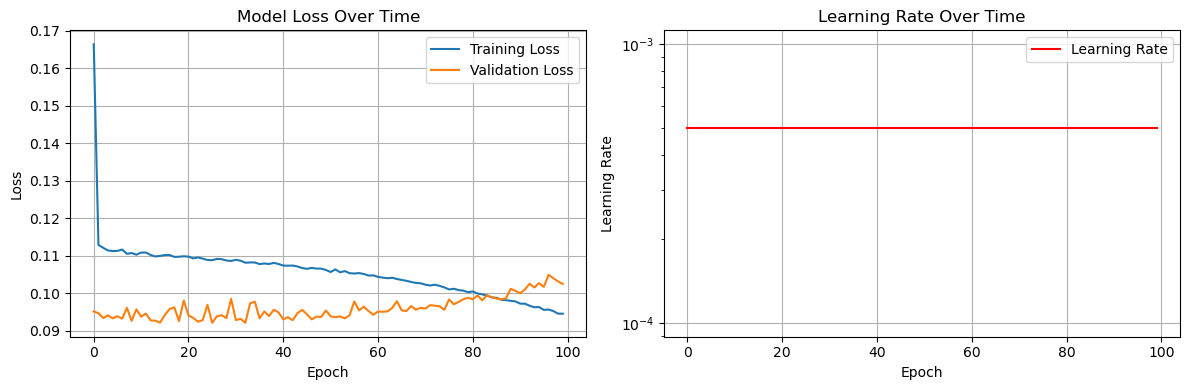

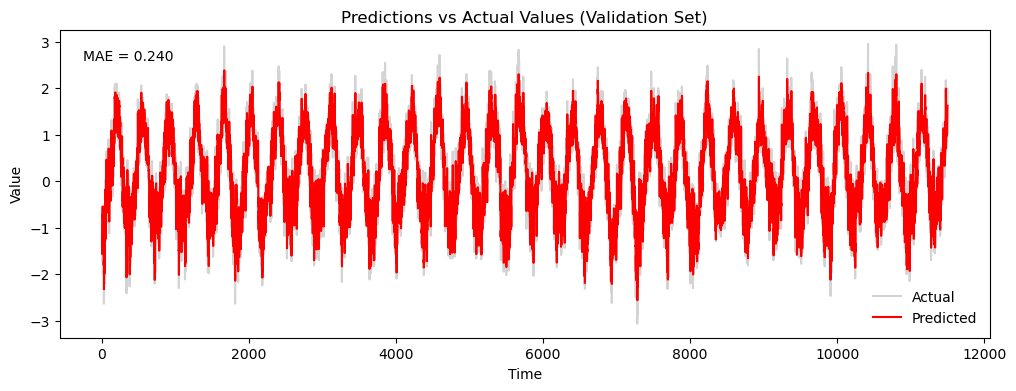

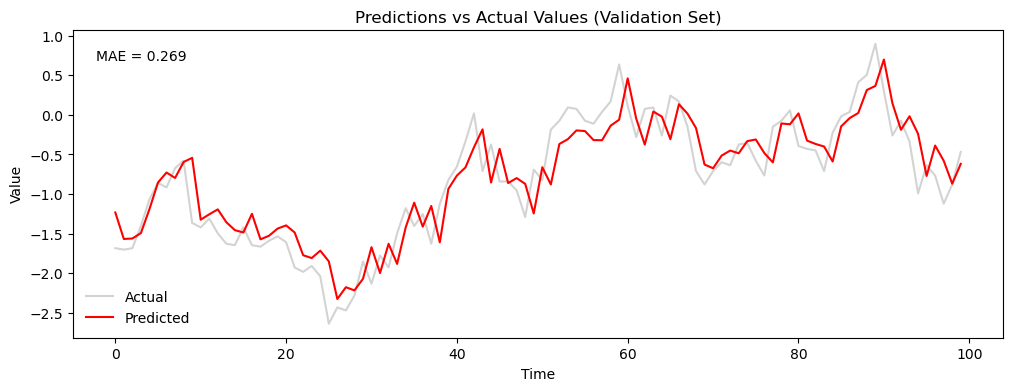

In [11]:
# Create the model
gru = TimeSeriesGatedRNN(
    type='GRU',
    input_size=window_size-1, 
    hidden_size=hidden_size,
    dropout_rate=dropout_rate,
    bidirectional=False
    ).to(device)

# train the model
gru, loss, history = train(
    gru,
    train_loader,
    val_loader,
    criterion=nn.MSELoss(),
    optimizer=optim.Adam(gru.parameters(), lr=learning_rate),
    epochs=epochs,
    patience=patience,
    verbose=10
)
plot_training(*history.values())

# Generate predictions
val_predictions, val_targets = predict(gru, val_loader)
plot_prediction(val_predictions, val_targets)
plot_prediction(val_predictions[:100], val_targets[:100])

### LSTM

In [12]:
# class TimeSeriesLSTM(nn.Module):
#     def __init__(self, input_size=1, hidden_size=100, output_size=1, dropout_rate=0.3):
#         super(TimeSeriesLSTM, self).__init__()

#         self.lstm1 = nn.LSTM(input_size=input_size,
#                             hidden_size=hidden_size,
#                             batch_first=True,
#                             dropout=dropout_rate)  # Add dropout to LSTM

#         self.lstm2 = nn.LSTM(input_size=hidden_size,
#                             hidden_size=hidden_size,
#                             batch_first=True,
#                             dropout=dropout_rate)  # Add dropout to LSTM

#         # Add more layers before final output
#         self.fc1 = nn.Linear(hidden_size, hidden_size)
#         self.relu = nn.ReLU()
#         self.linear = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out, _ = self.lstm1(x)  # LSTM returns (output, (h_n, c_n))
#         out, _ = self.lstm2(out)  # We ignore both hidden and cell states with _
#         out = out[:, -1, :]
#         out = self.relu(self.fc1(out))
#         output = self.linear(out)
#         return output

In [ ]:
# Create the model
lstm = TimeSeriesGatedRNN(
    type='LSTM',
    input_size=window_size-1,  
    hidden_size=hidden_size,
    dropout_rate=dropout_rate,
    bidirectional=False
    ).to(device)

# train the model
lstm, loss, history = train(
    lstm,
    train_loader,
    val_loader,
    criterion=nn.MSELoss(),
    optimizer=optim.Adam(lstm.parameters(), lr=learning_rate),
    epochs=epochs,
    patience=patience,
    verbose=10
)
plot_training(*history.values())

# Generate predictions
val_predictions, val_targets = predict(lstm, val_loader)
plot_prediction(val_predictions, val_targets)
plot_prediction(val_predictions[:100], val_targets[:100])

/home/casadoj/miniconda3/envs/torch/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
Epoch 10/100: 100%|██████████| 625/625 [00:03<00:00, 198.68it/s]


Epoch [10 / 100], Train Loss: 0.1107, Val Loss: 0.0972


Epoch 20/100: 100%|██████████| 625/625 [00:02<00:00, 227.57it/s]


Epoch [20 / 100], Train Loss: 0.1095, Val Loss: 0.0932


Epoch 30/100: 100%|██████████| 625/625 [00:03<00:00, 197.17it/s]


...

Epoch 40/100: 100%|██████████| 625/625 [00:03<00:00, 183.33it/s]


Epoch [40 / 100], Train Loss: 0.1064, Val Loss: 0.0929


Epoch 50/100: 100%|██████████| 625/625 [00:03<00:00, 190.17it/s]


Epoch [50 / 100], Train Loss: 0.1052, Val Loss: 0.0949


Epoch 59/100:  97%|█████████▋| 608/625 [00:03<00:00, 173.75it/s]

### Bidirectional GRU

In [ ]:
# class TimeSeriesBidirectionalGRU(nn.Module):
#     def __init__(self, input_size=1, hidden_size=100, output_size=1, dropout_rate=0.1):
#         super(TimeSeriesBidirectionalGRU, self).__init__()

#         self.gru1 = nn.GRU(
#             input_size=input_size,
#             hidden_size=hidden_size,
#             batch_first=True,
#             dropout=dropout_rate,
#             bidirectional=True
#             )

#         self.gru2 = nn.GRU(
#             input_size=hidden_size * 2,
#             hidden_size=hidden_size,
#             batch_first=True,
#             dropout=dropout_rate,
#             bidirectional=True
#             )

#         # Additional layers
#         self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(dropout_rate)
#         self.linear = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out1, _ = self.gru1(x)
#         out2, _ = self.gru2(out1)
#         last_out = out2[:, -1, :]

#         # Additional processing
#         x = self.fc1(last_out)
#         x = self.relu(x)
#         x = self.dropout(x)
#         output = self.linear(x)
#         return output

In [ ]:
# Create the model
bidir_gru = TimeSeriesGatedRNN(
    type='GRU',
    input_size=window_size-1, 
    hidden_size=hidden_size,
    dropout_rate=dropout_rate,
    bidirectional=True
    )

# train the model
bidir_gru, loss, history = train(
    bidir_gru,
    train_loader,
    val_loader,
    criterion=nn.MSELoss(),
    optimizer=optim.Adam(bidir.parameters(), lr=learning_rate),
    epochs=epochs,
    # patience=patience
)
plot_training(*history.values())

# Generate predictions
val_predictions, val_targets = predict(bidir_gru, val_loader)
plot_prediction(val_predictions, val_targets)
plot_prediction(val_predictions[:100], val_targets[:100])